In [253]:
import os, warnings
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
    module="keras.src.export.tf2onnx_lib"
)
import tensorflow as tf
import pandas as pd
from tensorflow import keras
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Conv2D, LSTM, Input, MaxPooling2D, Reshape, Bidirectional, StringLookup
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, TensorBoard
import cv2
import numpy as np
import matplotlib.pyplot as plt
from src.constants import *
from src.helpers import load_img
from sklearn.model_selection import train_test_split
from tensorflow.keras.backend import ctc_batch_cost, int_shape, ctc_decode

### File paths and labels

In [254]:
df = pd.read_csv(TRAIN_TSV, sep='\t', header=None, names=['file', 'label'])
df = df.dropna(subset=['label']).reset_index(drop=True) # 2 entries with no label
image_paths = [TRAIN_DIR + "/" + f for f in df["file"].values]
labels = df["label"].values

### Alphabet of possible values

In [255]:
import unicodedata
chars = list(set(char for label in labels for char in label))

for char in chars:
    script = unicodedata.name(char, 'idk')
    print(f"{char}: {script}")

max([len(label) for label in labels]) # the kaggle page said 40, this is just to confirm it
#len(chars) 107

Й: CYRILLIC CAPITAL LETTER SHORT I
о: CYRILLIC SMALL LETTER O
Ц: CYRILLIC CAPITAL LETTER TSE
Х: CYRILLIC CAPITAL LETTER HA
[: LEFT SQUARE BRACKET
c: LATIN SMALL LETTER C
ш: CYRILLIC SMALL LETTER SHA
!: EXCLAMATION MARK
0: DIGIT ZERO
р: CYRILLIC SMALL LETTER ER
ф: CYRILLIC SMALL LETTER EF
.: FULL STOP
К: CYRILLIC CAPITAL LETTER KA
Т: CYRILLIC CAPITAL LETTER TE
и: CYRILLIC SMALL LETTER I
С: CYRILLIC CAPITAL LETTER ES
й: CYRILLIC SMALL LETTER SHORT I
;: SEMICOLON
Ш: CYRILLIC CAPITAL LETTER SHA
p: LATIN SMALL LETTER P
в: CYRILLIC SMALL LETTER VE
ъ: CYRILLIC SMALL LETTER HARD SIGN
5: DIGIT FIVE
t: LATIN SMALL LETTER T
М: CYRILLIC CAPITAL LETTER EM
R: LATIN CAPITAL LETTER R
П: CYRILLIC CAPITAL LETTER PE
%: PERCENT SIGN
»: RIGHT-POINTING DOUBLE ANGLE QUOTATION MARK
у: CYRILLIC SMALL LETTER U
ж: CYRILLIC SMALL LETTER ZHE
': APOSTROPHE
Щ: CYRILLIC CAPITAL LETTER SHCHA
b: LATIN SMALL LETTER B
З: CYRILLIC CAPITAL LETTER ZE
Р: CYRILLIC CAPITAL LETTER ER
": QUOTATION MARK
«: LEFT-POINTING DOUBLE AN

40

In [256]:
# num_oov_indices means how many "unaccounted for" values we can get
# in the encoding it's 0 because all the values are exact, but for the decoding
# we have it at 1 (default value) because ctc needs a blank character to work properly

label_to_int = StringLookup(vocabulary=chars, num_oov_indices=0) # encode
label_to_str = StringLookup(vocabulary=label_to_int.get_vocabulary(), invert=True) # decode

### Dataset

In [ ]:
augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(
        factor= 2/180.0,
        fill_mode="reflect",
    ),
    tf.keras.layers.RandomZoom(
        height_factor= 0.0,
        width_factor= (-0.05, 0.05),
        fill_mode="reflect",
    ),
    tf.keras.layers.RandomContrast(0.15),
])

In [ ]:
def build_dataset(paths, labels, batch_size, training):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if training:
        ds = ds.shuffle(1024)

    def load_and_process(p, y):
        img = load_img(p)
        y = label_to_int(tf.strings.unicode_split(y, input_encoding="UTF-8"))
        y = tf.cast(y, tf.int32) + 1
        if training:
            img = augmentation(img, training=True)
        return {"img_input": img, "label_input": y}, y

    ds = ds.map(load_and_process, num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.padded_batch(
        batch_size,
        padded_shapes=({"img_input": [IM_HEIGHT, IM_WIDTH, 1], "label_input": [None]}, [None]),
        padding_values=({"img_input": 0.0, "label_input": 0}, 0)
    )
    
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

### 80/20 train dataset split

In [ ]:
# this is like 1/4 of the dataset but should be plenty
train_paths, val_paths, train_labels, val_labels = train_test_split(
    image_paths[:15000], labels[:15000], test_size=VALIDATION_SIZE, random_state=67)

train_ds = build_dataset(train_paths, train_labels, batch_size=32, training=True)
val_ds = build_dataset(val_paths, val_labels, batch_size=32, training=False)

### Model

In [260]:
class CTCLayer(tf.keras.layers.Layer):
    def __init__(self, name=None):
        super().__init__(name=name)
        self.loss_func = ctc_batch_cost

    def call(self, y_true, y_pred):
        batch_size = tf.cast(tf.shape(y_true)[0], tf.int32)
        input_len = tf.cast(tf.shape(y_pred)[1], tf.int32)
        input_len *= tf.ones((batch_size, 1), tf.int32)

        label_len = tf.math.count_nonzero(y_true, axis=1, keepdims=True)
        
        loss = self.loss_func(y_true, y_pred, input_len, label_len)
        self.add_loss(loss)
        return y_pred

In [ ]:
img_input = Input(shape=(IM_HEIGHT, IM_WIDTH, 1), name="img_input")
label_input = Input(shape=(None,), dtype=tf.int32, name="label_input")

# stride for a more general overview of the image, more precise conv later
x = Conv2D(64, 5, strides=4, padding="same", activation=tf.nn.leaky_relu, name="conv1")(img_input)
x = MaxPooling2D(name="pool1", pool_size=(4, 4))(x)

x = Conv2D(64, 3, padding="same", activation=tf.nn.leaky_relu, name="conv2")(x)
x = MaxPooling2D(name="pool2")(x)

shape = int_shape(x)
h, w, c = shape[1], shape[2], shape[3]
x = Reshape(target_shape=(w, h * c), name="shape1")(x)
x = Dense(192, activation=tf.nn.leaky_relu, name="dense1")(x)

x = Bidirectional(LSTM(128, return_sequences=True), name="lstm1")(x)
x = Bidirectional(LSTM(96, return_sequences=True), name="lstm2")(x)

x = Dense(len(chars)+2, activation="softmax", name="softmax")(x) # +1 for the blank char and +1 for padding

output = CTCLayer(name="ctc")(label_input, x)

model = Model(inputs=[img_input, label_input], outputs=output)
model.compile(optimizer="adam")
model.summary()

Model: "functional_53"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ img_input           │ (None, 200, 800,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv2D)      │ (None, 50, 200,   │      1,664 │ img_input[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 12, 50,    │          0 │ conv1[0][0]       │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2 (Conv2D)      │ (None, 12, 50,    │     36,928 │ pool1[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool2               │ (None, 6, 25, 64) │          0 │ conv2[0][0]       │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shape1 (Reshape)    │ (None, 25, 384)   │          0 │ pool2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense1 (Dense)      │ (None, 25, 192)   │     73,920 │ shape1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm1               │ (None, 25, 256)   │    328,704 │ dense1[0][0]      │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm2               │ (None, 25, 192)   │    271,104 │ lstm1[0][0]       │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ label_input         │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softmax (Dense)     │ (None, 25, 109)   │     21,037 │ lstm2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ctc (CTCLayer)      │ (None, 25, 109)   │          0 │ label_input[0][0… │
│                     │                   │            │ softmax[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 733,357 (2.80 MB)

 Trainable params: 733,357 (2.80 MB)

 Non-trainable params: 0 (0.00 B)

### Overfitting experiment

In [263]:
overfit_ds = build_dataset(train_paths[:5], train_labels[:5], 5, False)
# for input, _ in overfit_ds.take(1):
    # print(input['img_input'].shape)
    # print(input['label_input'].shape)
    # print(label_to_str(input['label_input']))

# early = EarlyStopping(monitor="loss", patience=15, restore_best_weights=True)
# reduce = ReduceLROnPlateau(monitor="loss", patience=5)

model.fit(overfit_ds, epochs=1000)


(5, 200, 800, 1)
(5, 13)
tf.Tensor(
[[b'\xd0\xb6' b'\xd0\xb8' b'\xd1\x82' b'\xd1\x8c' b'[UNK]' b'[UNK]'
  b'[UNK]' b'[UNK]' b'[UNK]' b'[UNK]' b'[UNK]' b'[UNK]' b'[UNK]']
 [b'\xd0\x90' b'\xd0\xb7' b'\xd0\xbe' b'\xd0\xb2' b'\xd1\x81' b'\xd0\xba'
  b'\xd0\xbe' b'\xd0\xb3' b'\xd0\xbe' b'[UNK]' b'[UNK]' b'[UNK]' b'[UNK]']
 [b'\xd0\xbf' b'\xd0\xbe' b' ' b'\xd1\x80' b'\xd0\xbe' b'\xd1\x82'
  b'[UNK]' b'[UNK]' b'[UNK]' b'[UNK]' b'[UNK]' b'[UNK]' b'[UNK]']
 [b'\xd0\xbd' b'\xd0\xb5' b'\xd0\xbc' b'[UNK]' b'[UNK]' b'[UNK]' b'[UNK]'
  b'[UNK]' b'[UNK]' b'[UNK]' b'[UNK]' b'[UNK]' b'[UNK]']
 [b'\xd0\xb4' b'\xd0\xb2' b'\xd0\xb8' b'\xd0\xb3' b'\xd0\xb0' b'\xd1\x82'
  b'\xd0\xb5' b'\xd0\xbb' b'\xd1\x8c' b'\xd0\xbd' b'\xd0\xbe' b'\xd0\xb3'
  b'\xd0\xbe']], shape=(5, 13), dtype=string)
Epoch 1/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step - loss: 109.1480
Epoch 2/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 108.6073
Epoch 3/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 107.9146
Epoch 4/1000
1/1 ━

In [ ]:
y_pred = model.predict(overfit_ds)

def decode_output(y_pred) -> list[str]:
    input_len = np.ones(y_pred.shape[0]) * y_pred.shape[1]
    decoded, _ = tf.keras.backend.ctc_decode(y_pred, input_len, greedy=True)

    res = []
    for seq in decoded[0].numpy():
        seq = seq[seq != -1]
        text = b"".join(label_to_str(seq).numpy()).decode("utf-8")
        res.append(text)
    return res

print(decode_output(y_pred))
print(list(train_labels[:5]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
['жить', 'Азовского', 'по рот', 'нем', 'двигательного']
['жить', 'Азовского', 'по рот', 'нем', 'двигательного']


Real label: жить


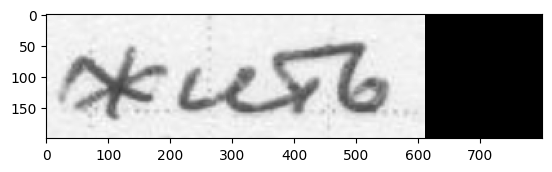

In [269]:
for input, _ in overfit_ds.take(1):
    plt.imshow(input['img_input'][0, :, :, 0], cmap="gray", interpolation="nearest")
    print(f"Real label: {train_labels[0]}") # жить